# Equilibrium shortcut vs. brute force — *same answer, and how?*

Two questions, answered head-on:

1. **Do the fast shortcut (`lunar/equilibrium.py`) and a long brute-force
   spin-up give the same result?** → Demonstration 1 overlays the profiles.
2. **How does the shortcut reach the true steady state without the long
   integration?** → explained just below, then demonstrated.

## How the shortcut reaches the true value

The true periodic steady state is pinned by **two physical facts** — not by
waiting:

1. **The surface skin** repeats a daily cycle set by sunlight, and it settles
   *fast* (~10 lunations).
2. **Deep down**, at steady state there are no heat sources in the rock, so the
   *same* heat flows through every layer: the geothermal flux $Q_b$ from below.
   That **fixes the temperature gradient at every depth**:
   $$\frac{d\langle T\rangle}{dz} = \frac{Q_b}{K(\langle T\rangle,\,z)}.$$

**Key insight:** the deep profile's *shape* is not a free unknown you must
discover by waiting — it is fixed by energy conservation.

- **Brute force** discovers it slowly: start from an arbitrary temperature and
  let heat physically diffuse for ~$10^3$ lunations until the deep gradient
  relaxes to $Q_b/K$. The waiting is just the rock forgetting its arbitrary
  start (diffusion through 5 m is slow).
- **The shortcut** *uses* the gradient law instead of waiting for it:
  1. a **short** spin-up (~12 lunations) settles the fast skin and gives the
     correct temperature at one **anchor** depth (~0.55 m);
  2. from that anchor it **integrates $dT/dz = Q_b/K$ straight down** to fill
     the entire deep profile *instantly*;
  3. feed that back into another short spin-up and repeat — 3–5 rounds, because
     the surface temperature barely depends on the deep column.

The only thing it "assumes" is the gradient law — and that law is **exact** at
steady state (energy conservation + the bottom boundary condition). So both
methods *must* land on the same profile.

**Analogy:** filling a tank to find its steady level. Brute force pours water in
and waits for the sloshing to stop; the shortcut knows the level is set by
inflow = outflow and computes it directly. Same level — one just doesn't wait.

In [1]:
import sys, os, time, pathlib
ROOT = pathlib.Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT)); sys.path.insert(0, str(ROOT / "src")); sys.path.insert(0, str(ROOT / "pipeline" / "figures"))
import make_equilibrium_demo as demo
print("project root:", ROOT, "| CPU cores:", os.cpu_count())

project root: /Users/rp3gregorio/Developer/Lunar-Clean/code | CPU cores: 6


## Demonstration 1 — same answer (the overlay)

Run brute force toward convergence from **two different starting temperatures**
(240 K and 260 K) and overlay the final profiles on the shortcut. If the
mechanism above is right, all three curves lie on top of each other.

`N_LUN` sets how far brute force runs. The committed reference figure
[`results/figures/fig_equilibrium_demo.pdf`](../results/figures/fig_equilibrium_demo.pdf)
was made at **N_LUN = 3000** (agreement **60–95 mK** over the sensor depths —
the small residual is brute force still crawling the last bit; the shortcut
reached the same place in ~9 s). Increase `N_LUN` to shrink the residual;
decrease it for a quicker look. Runtime ≈ `N_LUN`×0.09 s per run, two runs in
parallel.

In [2]:
N_LUN        = 2000          # lunations per brute-force run (3000 ~ 60-95 mK; bump higher to tighten)
GUESSES      = (240.0, 260.0)
USE_PARALLEL = True          # two runs across two cores; set False to run serially

In [3]:
t0 = time.perf_counter()
res = demo.converged_profiles(n_lun=N_LUN, guesses=GUESSES, parallel=USE_PARALLEL)
print(f"shortcut: {res['shortcut']['wall']:.1f} s   |   brute force: {time.perf_counter()-t0:.0f} s wall\n")
for g in sorted(res["profiles"]):
    print(f"  start {g:.0f} K  ->  agrees with shortcut to "
          f"{res['resid_sensor'][g]*1e3:5.1f} mK over sensor depths "
          f"(0.8-2.4 m),  {res['resid_full'][g]*1e3:4.0f} mK over the full column")

shortcut: 98.4 s   |   brute force: 1813 s wall

  start 240 K  ->  agrees with shortcut to 387.6 mK over sensor depths (0.8-2.4 m),   569 mK over the full column
  start 260 K  ->  agrees with shortcut to  48.5 mK over sensor depths (0.8-2.4 m),    71 mK over the full column


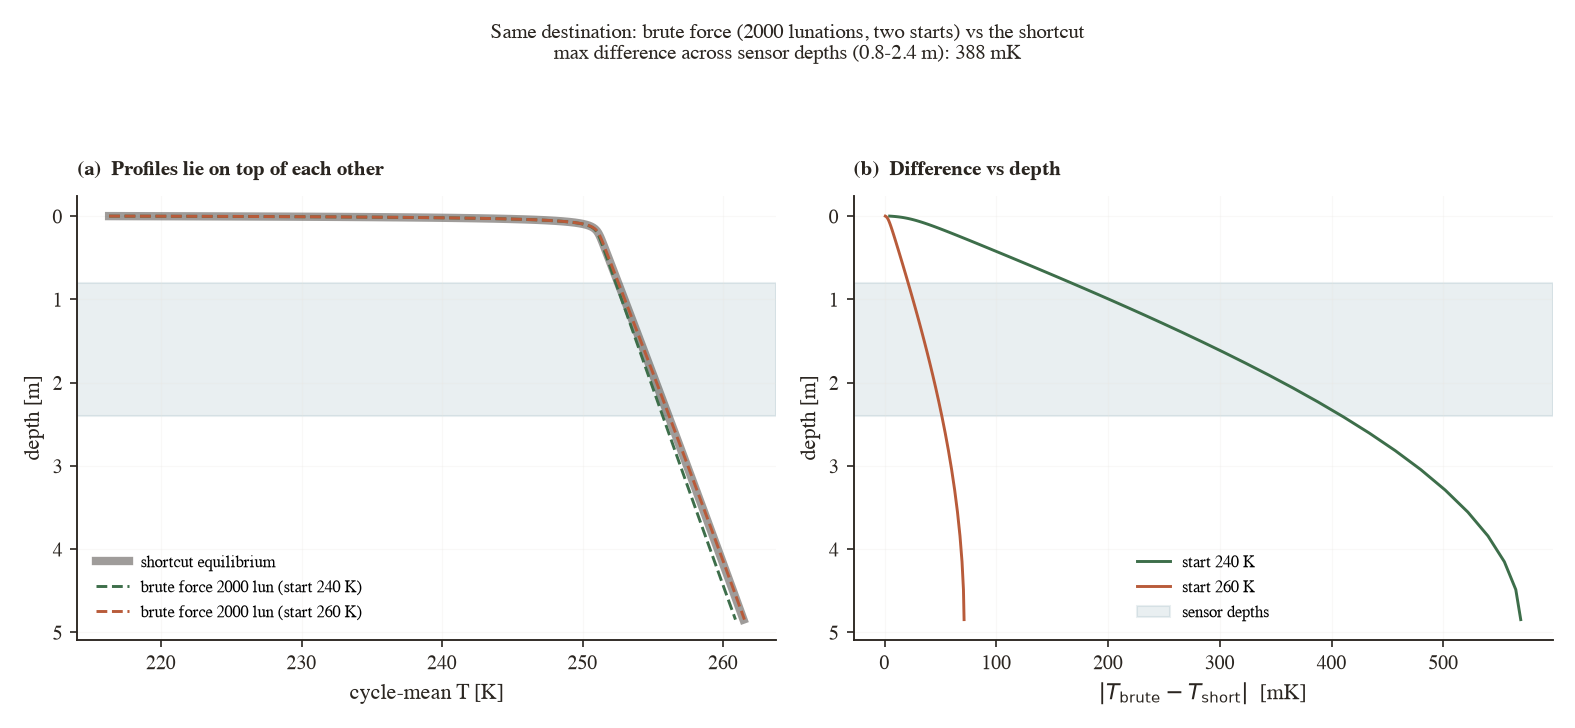

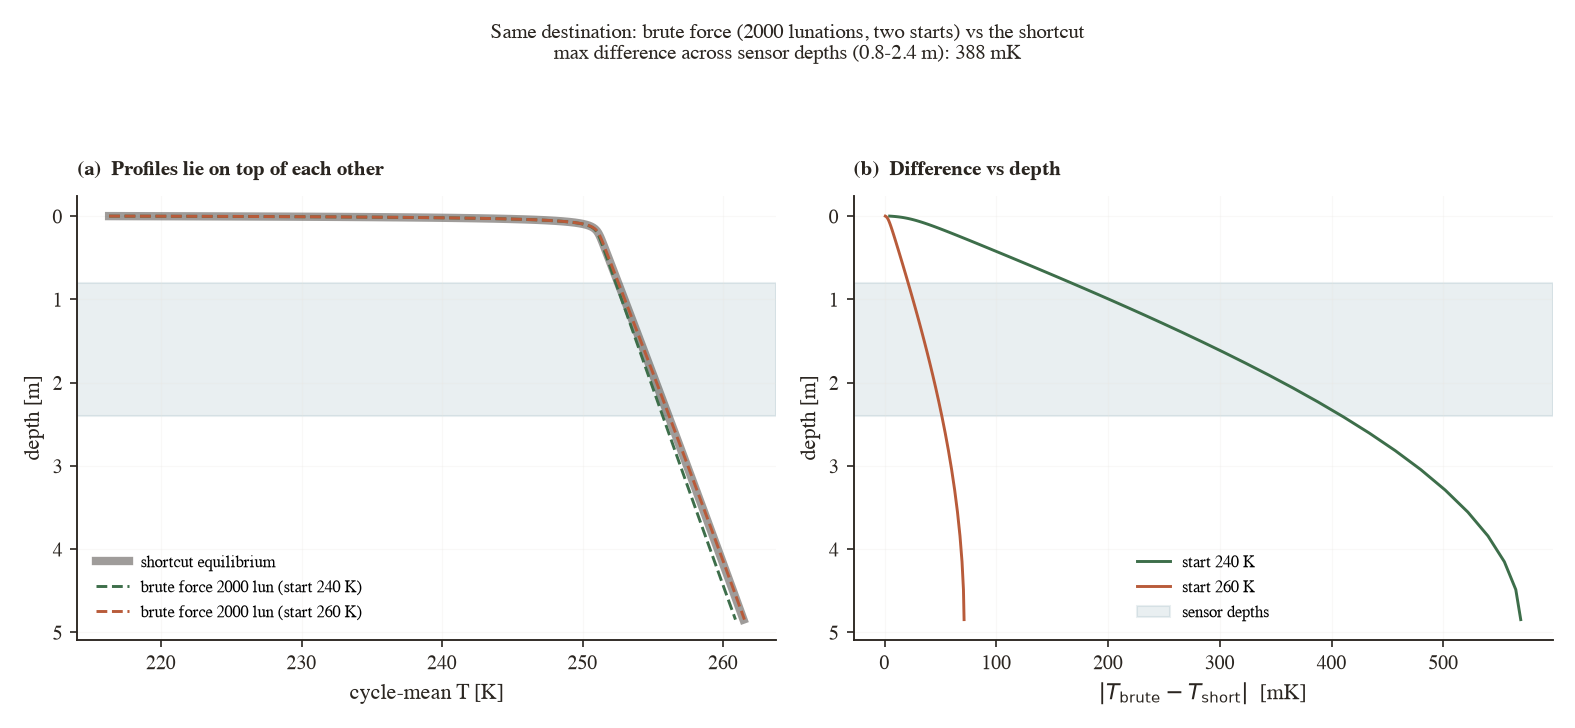

In [4]:
fig = demo.plot_overlay(res)
fig

**How to read it.** In panel (a) the thick grey shortcut profile and both dashed
brute-force profiles (from 240 K and 260 K) are indistinguishable — two very
different starts and the direct method all reach one profile. Panel (b) shows
the leftover difference: tens of mK, and it is purely brute force *still
converging* (the deep middle of the column relaxes slowest). The shortcut hits
this in ~9 s; brute force needs thousands of lunations to match it.

## Demonstration 2 (optional) — *why* brute force is slow

The convergence *rate*: how the brute-force error shrinks as lunations are
added, from each starting guess. This is the "waiting for diffusion" cost the
shortcut avoids. (Independent runs across `N_GRID` × `GUESSES` are fanned over
all your cores.)

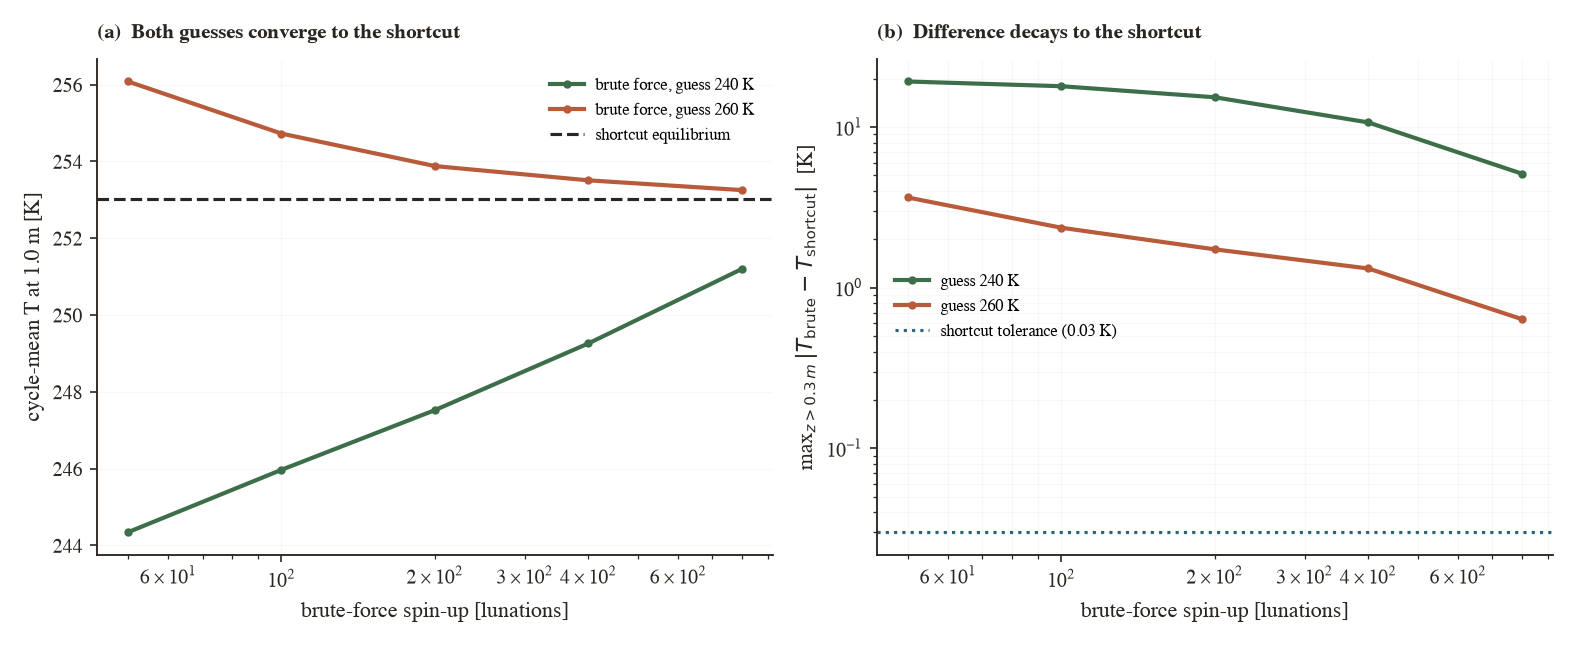

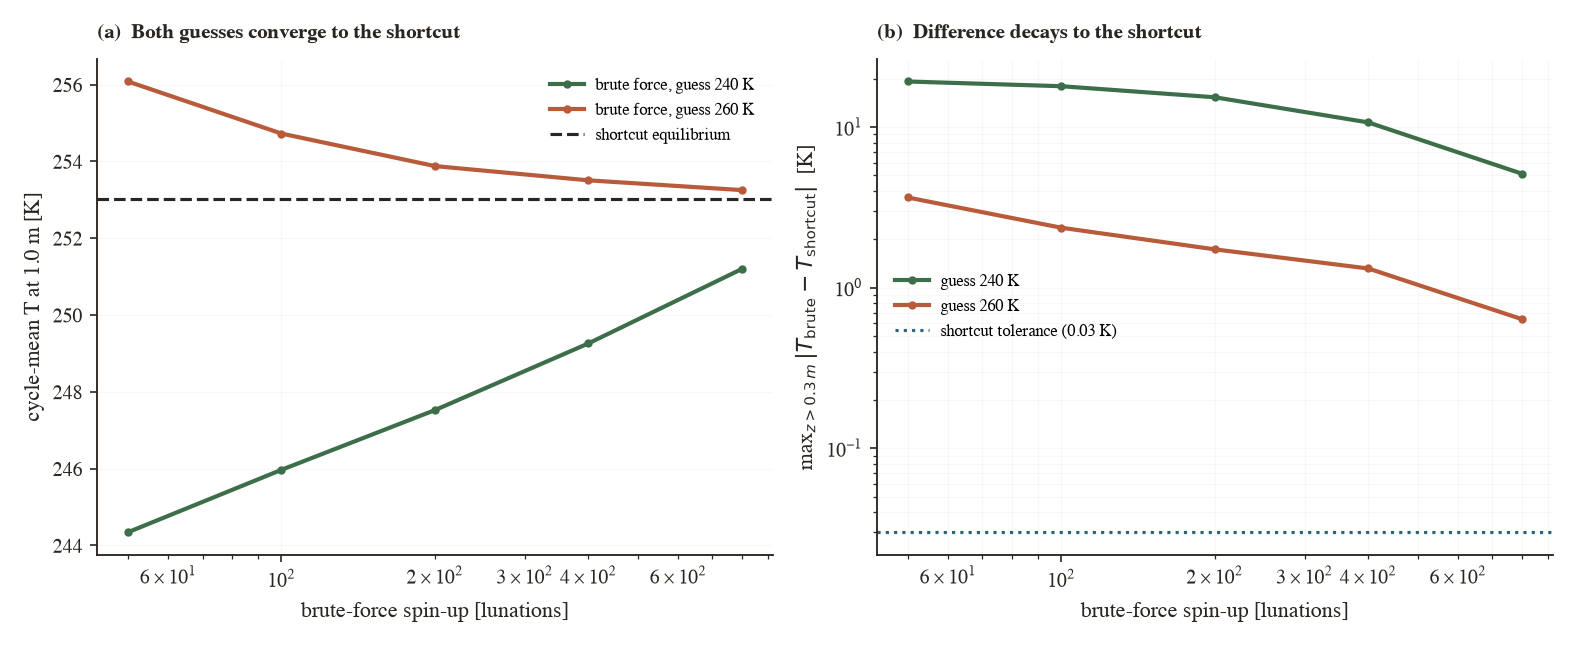

In [5]:
res2 = demo.compute_curves(n_grid=(50, 100, 200, 400, 800),
                           guesses=GUESSES, parallel=USE_PARALLEL)
fig2 = demo.plot_curves(res2)
fig2

## Takeaway

- **Same destination:** brute force from any start converges onto the shortcut's
  profile — they solve the same steady-state problem.
- **~30× less work:** the shortcut reaches it in ~9 s; brute force needs
  ~3000 lunations (~4 min) to match it to the shortcut's certified tolerance.
- **And it's certified:** the shortcut returns `drift` and `flux_closure`
  diagnostics proving it arrived — you don't have to guess how many lunations
  is "enough" (the trap that produced the original biased result, flag F1).

## Instantaneous profiles from the converged cycle — `profile_at_time`

The converged steady state is **periodic**, and the solver keeps the **entire final
lunar cycle** (`eq.out.T`, shape `(N_z, N_t)`) — the cycle-mean profile everyone
plots is literally its time-average. So once you have a converged result you can ask
for the temperature profile **at any moment of the lunar day** with no extra solving:

```python
from lunar.equilibrium import profile_at_time
T_z = profile_at_time(eq, "noon")      # named phase ...
T_z = profile_at_time(eq, 200.0)       # ... or hours past lunar noon (wraps periodically)
```

Times wrap: a "time that occurred before" maps onto its phase of the ~708.7 h lunation
(`profile_at_time(eq, 100 - 708.73)` equals `profile_at_time(eq, 100)`). Expect the
skin to swing by hundreds of K while everything below ~0.5 m sits on the cycle mean —
that is the anchor-method fact in action.

In [6]:
# One production Apollo 15 solve at the retrieved K_d* (about 14 s)
import functools, numpy as np
from lunar.config import SITES, GRID, HAYNE, S0, T_LUNAR, DT_STEP
from lunar.grid import make_geometric_grid
from lunar.properties import conductivity_hayne, specific_heat
from lunar.solver import standard_insolation, periodic_time_grid
from lunar.equilibrium import solve_periodic_equilibrium, profile_at_time

site = SITES["A15"]
g = make_geometric_grid(**GRID)
t = periodic_time_grid(DT_STEP)
insol = standard_insolation(site["lat"], t)  # raw flux; solver applies (1-A)
K  = functools.partial(conductivity_hayne, Ks=HAYNE["K_S"], Kd=4.603e-3,
                       H=HAYNE["H"], chi=HAYNE["CHI"])
cp = functools.partial(specific_heat, model="hayne")

eq = solve_periodic_equilibrium(grid=g, t=t, insolation=insol,
        albedo=site["albedo"], emissivity=site["emissivity"], Q_b=site["Q_BASAL"],
        K_func=K, cp_func=cp, T_guess=site["T_MEAN_EFF"])
print(f"converged: {eq.converged}   anchor <T>(z0) = {eq.anchor_K:.2f} K")

converged: True   anchor <T>(z0) = 251.93 K


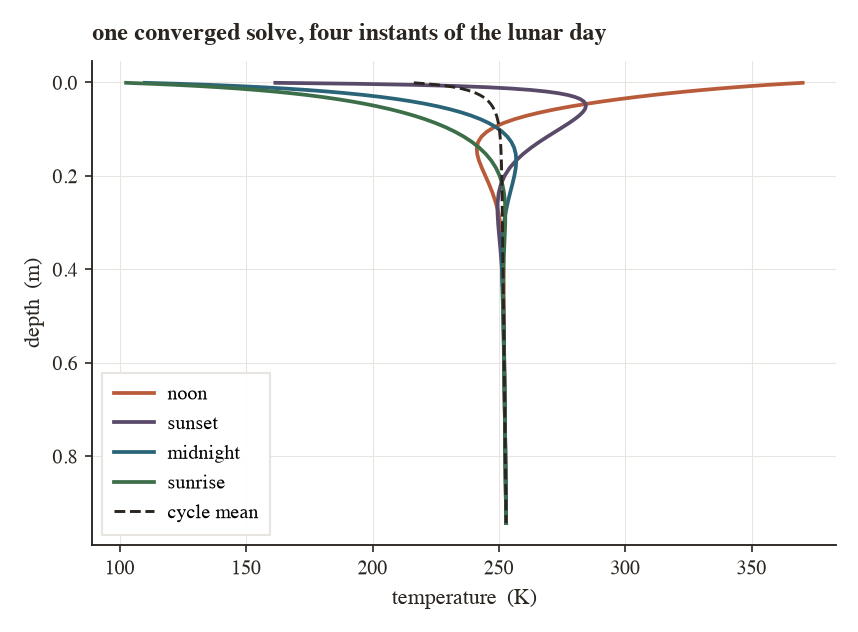

t =     0.00 h past noon  ->  T(surface) =  370.2 K,  T(1 m) = 253.03 K
t =   200.00 h past noon  ->  T(surface) =  133.3 K,  T(1 m) = 253.03 K
t =   500.00 h past noon  ->  T(surface) =  102.9 K,  T(1 m) = 253.03 K
t =  -508.73 h past noon  ->  T(surface) =  133.3 K,  T(1 m) = 253.03 K


In [7]:
# The profile at four moments of the lunar day + an arbitrary past time
import matplotlib.pyplot as plt
from lunar.plotting.style import (JGR_HALF, C_CORAL, C_TEAL, C_FOREST, C_PLUM,
                                  C_CHAR, C_GRID, fmt_axis, assert_no_overlap)

z = eq.out.z
moments = [("noon", C_CORAL), ("sunset", C_PLUM), ("midnight", C_TEAL), ("sunrise", C_FOREST)]

fig, ax = plt.subplots(figsize=(JGR_HALF, 4.0), constrained_layout=True)
m = z <= 1.0
for name, c in moments:
    ax.plot(profile_at_time(eq, name)[m], z[m], color=c, lw=1.8, label=name)
ax.plot(eq.T_mean[m], z[m], "--", color=C_CHAR, lw=1.4, label="cycle mean")
ax.invert_yaxis()
fmt_axis(ax, xlabel="temperature  (K)", ylabel="depth  (m)",
         title="one converged solve, four instants of the lunar day")
ax.legend(frameon=True, edgecolor=C_GRID, loc="lower left")
fig.canvas.draw(); assert_no_overlap(ax)
plt.show()

# 'a specific time that occurred before': just plug in the hours
for h in (0.0, 200.0, 500.0, 200.0 - 708.73):     # note the wrap on the last one
    Tz = profile_at_time(eq, h)
    print(f"t = {h:8.2f} h past noon  ->  T(surface) = {Tz[0]:6.1f} K,  "
          f"T(1 m) = {Tz[np.argmin(np.abs(z-1.0))]:6.2f} K")

## Just plug in a local time — `profile_at_local_time`

`profile_at_time` above takes "hours past noon", which is precise but not how
anyone actually thinks about time of day. `profile_at_local_time` wraps it in
an ordinary 24-hour clock, stretched over one lunation instead of one Earth
day:

| clock reading | meaning |
|---|---|
| `12:00` | local noon — hottest surface |
| `00:00` | local midnight — coldest surface |
| `06:00` | sunrise |
| `18:00` | sunset |

Pass a float (`14.5`) or a `"HH:MM"` string (`"14:30"`); readings outside
`[0, 24)` wrap the way a clock does (`25:00` == `01:00`). No re-solve — same
stored cycle as before, just a friendlier front door.

In [8]:
from lunar.equilibrium import profile_at_local_time

# put in a local time, get the profile back
T_afternoon = profile_at_local_time(eq, "14:30")
T_predawn   = profile_at_local_time(eq, 4.0)

z = eq.out.z
i1m = np.argmin(np.abs(z - 1.0))
print(f"14:30 local  ->  T(surface) = {T_afternoon[0]:6.1f} K,  T(1 m) = {T_afternoon[i1m]:6.2f} K")
print(f"04:00 local  ->  T(surface) = {T_predawn[0]:6.1f} K,  T(1 m) = {T_predawn[i1m]:6.2f} K")

14:30 local  ->  T(surface) =  351.6 K,  T(1 m) = 253.03 K
04:00 local  ->  T(surface) =  103.9 K,  T(1 m) = 253.03 K


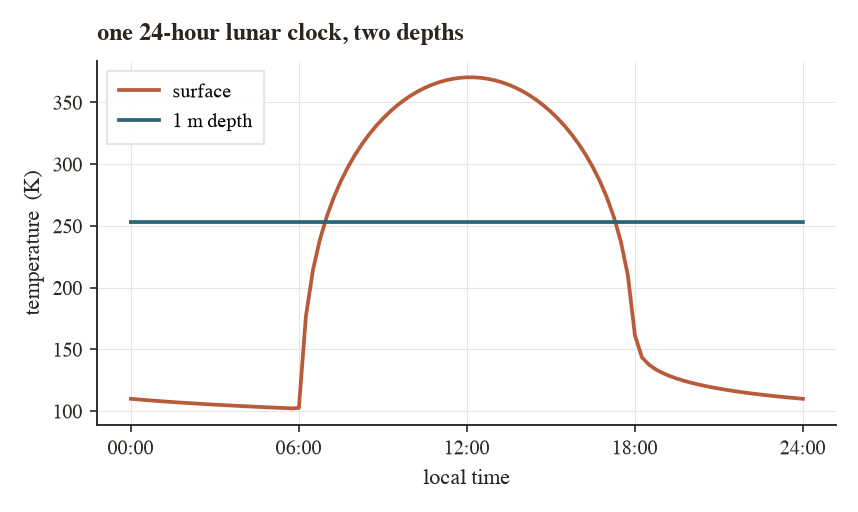

In [9]:
# sweep the whole 24-hour clock and watch the surface swing while 1 m barely moves
import matplotlib.pyplot as plt
from lunar.plotting.style import JGR_HALF, C_CORAL, C_TEAL, C_GRID, fmt_axis, assert_no_overlap

clock = np.linspace(0, 24, 97)   # every 15 minutes, wrapping back to 24:00
T_surf = np.array([profile_at_local_time(eq, h)[0] for h in clock])
T_1m   = np.array([profile_at_local_time(eq, h)[i1m] for h in clock])

fig, ax = plt.subplots(figsize=(JGR_HALF, 3.2), constrained_layout=True)
ax.plot(clock, T_surf, color=C_CORAL, lw=1.8, label="surface")
ax.plot(clock, T_1m, color=C_TEAL, lw=1.8, label="1 m depth")
ax.set_xticks([0, 6, 12, 18, 24])
ax.set_xticklabels(["00:00", "06:00", "12:00", "18:00", "24:00"])
fmt_axis(ax, xlabel="local time", ylabel="temperature  (K)",
         title="one 24-hour lunar clock, two depths")
ax.legend(frameon=True, edgecolor=C_GRID, loc="upper left")
fig.canvas.draw(); assert_no_overlap(ax)
plt.show()